<a href="https://colab.research.google.com/github/HARSITHRAM/Interactive-Online-Class/blob/main/int_class03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install paho-mqtt deepface
!wget https://github.com/googlefonts/roboto/raw/main/src/hinted/Roboto-Bold.ttf -O /content/bold.ttf
!apt-get update
!apt-get install -y libfreetype6-dev libpng-dev
!pip install -U Pillow

--2025-04-11 14:53:08--  https://github.com/googlefonts/roboto/raw/main/src/hinted/Roboto-Bold.ttf
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/googlefonts/roboto-2/raw/main/src/hinted/Roboto-Bold.ttf [following]
--2025-04-11 14:53:08--  https://github.com/googlefonts/roboto-2/raw/main/src/hinted/Roboto-Bold.ttf
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/googlefonts/roboto-2/main/src/hinted/Roboto-Bold.ttf [following]
--2025-04-11 14:53:08--  https://raw.githubusercontent.com/googlefonts/roboto-2/main/src/hinted/Roboto-Bold.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.

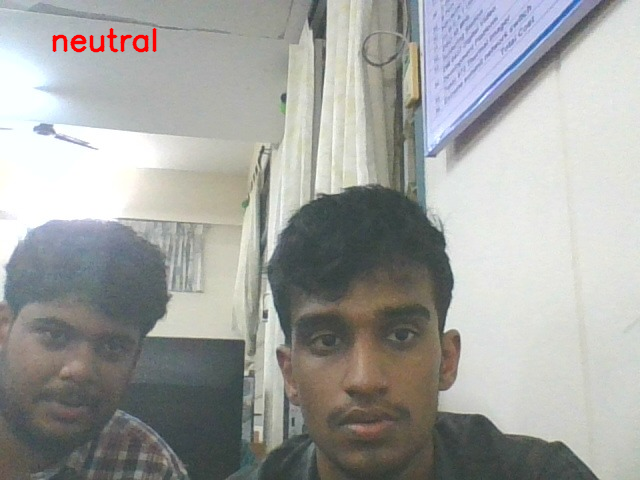


❌ Interrupted by user.
Process finished.


In [2]:
from google.colab.patches import cv2_imshow
from IPython.display import display, clear_output, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
from PIL import Image
from deepface import DeepFace
import paho.mqtt.client as mqtt
import socket
import time
import re

# === Convert JS object to OpenCV image ===
def js_to_image(js_reply):
    image_bytes = b64decode(js_reply.split(',')[1])
    jpg_as_np = np.frombuffer(image_bytes, dtype=np.uint8)
    return cv2.imdecode(jpg_as_np, flags=1)

# === Add emotion text on image ===
def overlay_emotion_text(frame, emotion, position=(50, 50)):
    cv2.putText(frame, emotion, position, cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2, cv2.LINE_AA)

# === Capture one frame from webcam ===
def video_frame():
    js = eval_js('''
        async function captureImage() {
            const video = document.createElement('video');
            const canvas = document.createElement('canvas');
            const ctx = canvas.getContext('2d');
            const stream = await navigator.mediaDevices.getUserMedia({ video: true });
            video.srcObject = stream;
            await video.play();
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            ctx.drawImage(video, 0, 0, canvas.width, canvas.height);
            stream.getTracks().forEach(t => t.stop());
            return canvas.toDataURL('image/jpeg');
        }
        captureImage();
    ''')
    return js

# === MQTT setup ===
broker_address = "b7567dff6628421e8bfca997634b396b.s1.eu.hivemq.cloud"
broker_port = 8883
topic = "teacher_input"
status_topic = "student_status"

client = mqtt.Client(client_id="colab_publisher", protocol=mqtt.MQTTv311)
client.tls_set()
client.username_pw_set("HARSITHRAM", "Ram@2005")

student_name = "student_01"
latest_emotion = None
active_emotions = ["happy", "neutral"]
inactive_emotions = ["sad", "angry", "disgust", "fear", "surprise"]
teacher_request = ""
send_active_status = False

# === Extract student name from teacher message ===
def extract_student_name(message):
    match = re.search(r'(student_\d+)', message.lower())
    return match.group(1) if match else None

# === MQTT Callback ===
def on_message(client, userdata, msg):
    global send_active_status, teacher_request
    message = msg.payload.decode()
    print(f"\n📩 Received message from teacher: {message}")
    teacher_request = message
    name = extract_student_name(message)
    if name == student_name:
        send_active_status = True
    else:
        print("ℹ️ No matching student name found.")

client.on_message = on_message

# === Connect to MQTT ===
try:
    client.connect(broker_address, broker_port)
    client.subscribe(topic)
    client.loop_start()
    print("✅ Connected and subscribed to MQTT broker")
except Exception as e:
    print(f"❌ MQTT Connection error: {e}")

# === Main Loop ===
try:
    frame_count = 0
    while True:
        js_reply = video_frame()
        frame = js_to_image(js_reply)

        # Resize image for faster processing
        resized_frame = cv2.resize(frame, (480, int(frame.shape[0] * 480 / frame.shape[1])))

        if frame_count % 2 == 0:  # Run emotion check every 4 seconds (assuming sleep = 2)
            try:
                result = DeepFace.analyze(
                    resized_frame,
                    actions=['emotion'],
                    enforce_detection=False,
                    model_name='Emotion'  # Use only emotion model for speed
                )

                emotion = result[0]['dominant_emotion']
                latest_emotion = emotion
                overlay_emotion_text(frame, f"{student_name}: {emotion}")

                # Show frame
                clear_output(wait=True)
                display(Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))

                # Send 'not active' immediately
                if emotion in inactive_emotions:
                    client.publish(status_topic, f"{student_name} is not active")

                # Send 'active' if teacher requested
                if send_active_status:
                    msg = f"{student_name} is active" if emotion in active_emotions else f"{student_name} is not active"
                    client.publish(status_topic, msg)
                    send_active_status = False

            except Exception as e:
                print(f"⚠️ Emotion analysis failed: {e}")

        else:
            # Still show video frame (optional)
            overlay_emotion_text(frame, f"Processing...", position=(50, 50))
            clear_output(wait=True)
            display(Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))

        frame_count += 1
        time.sleep(2)

except KeyboardInterrupt:
    print("\n🛑 Interrupted by user.")
finally:
    client.loop_stop()
    cv2.destroyAllWindows()
    print("🔚 Process finished.")
